# 🌌 Asteroid Hazard Prediction
**Applied AI Study Group #10 — Week 1 Workshop**

Bu notebook'ta NASA'nın asteroid verilerini kullanarak bir **tehlike tespit modeli** kuracağız.

## Problem
Bir asteroidin Dünya'ya tehlikeli olup olmadığını tahmin edebilir miyiz?

- **Input:** Asteroidin fiziksel ve orbital özellikleri
- **Output:** Tehlikeli mi? (1 = Hazardous, 0 = Not Hazardous)
- **ML Problem Type:** Binary Classification

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete')

✅ Setup complete


## 2. Load Data

In [ ]:
df = pd.read_csv('asteroids.csv')
print(f'Dataset shape: {df.shape}')
print(f'Hazardous: {df.is_hazardous.sum()} ({df.is_hazardous.mean()*100:.1f}%)')
print(f'Not hazardous: {(~df.is_hazardous.astype(bool)).sum()} ({(1-df.is_hazardous.mean())*100:.1f}%)')
df.head()

Dataset shape: (1000, 8)
Hazardous: 361 (36.1%)
Not hazardous: 639 (63.9%)


,name,est_diameter_km,relative_velocity_km_s,miss_distance_mKm,absolute_magnitude,eccentricity,inclination_deg,is_hazardous
0,Asteroid_0000,0.2346,10.55,9.10,21.7,0.5148,11.81,0
1,Asteroid_0001,1.5051,21.26,8.51,23.0,0.7249,14.20,1
2,Asteroid_0002,0.6584,31.19,71.02,17.5,0.6841,25.64,1
3,Asteroid_0003,0.4565,26.97,8.61,21.2,0.1385,10.20,1
4,Asteroid_0004,0.0848,29.20,9.52,20.7,0.1343,26.09,1


### Feature Descriptions

| Feature | Description | Unit |
|---------|-------------|------|
| `est_diameter_km` | Estimated diameter | km |
| `relative_velocity_km_s` | Speed relative to Earth | km/s |
| `miss_distance_mKm` | Closest approach distance | million km |
| `absolute_magnitude` | Brightness (lower = larger/closer) | — |
| `eccentricity` | Orbital eccentricity (0=circle, 1=parabola) | — |
| `inclination_deg` | Orbital inclination | degrees |

## 3. Exploratory Data Analysis (EDA)

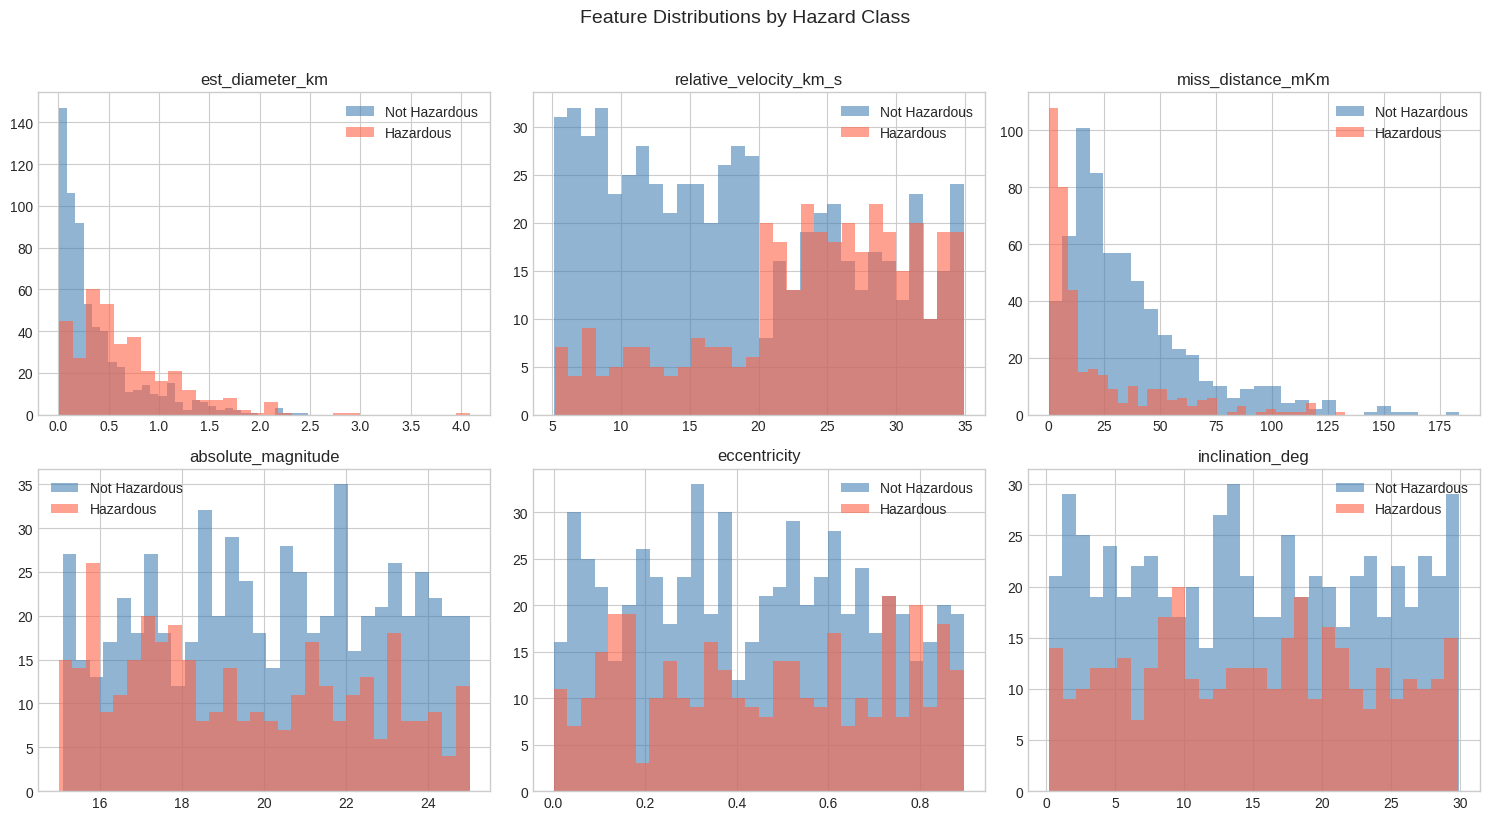

In [ ]:
# Distribution of each feature by hazard class
features = ['est_diameter_km', 'relative_velocity_km_s', 'miss_distance_mKm',
            'absolute_magnitude', 'eccentricity', 'inclination_deg']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    df[df.is_hazardous == 0][feat].hist(ax=ax, alpha=0.6, label='Not Hazardous',
                                         color='steelblue', bins=30)
    df[df.is_hazardous == 1][feat].hist(ax=ax, alpha=0.6, label='Hazardous',
                                         color='tomato', bins=30)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions by Hazard Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

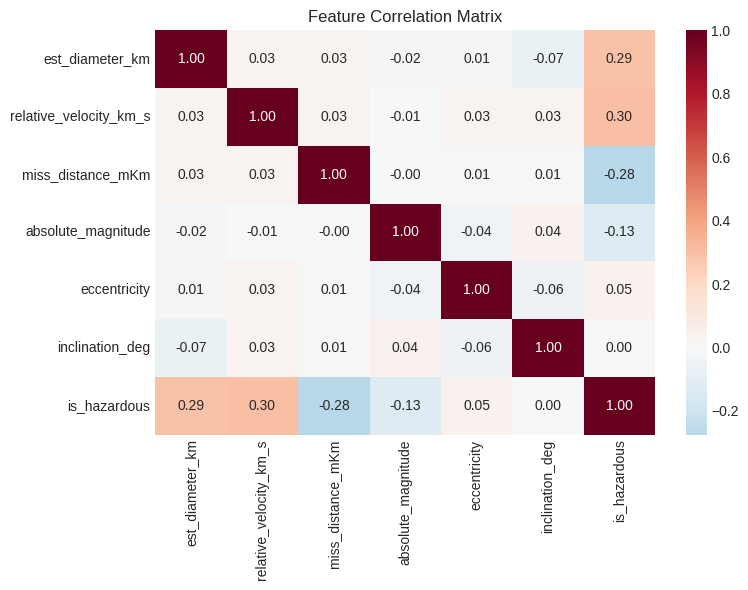


Correlation with is_hazardous:
relative_velocity_km_s    0.302415
est_diameter_km           0.291405
eccentricity              0.048498
inclination_deg           0.003302
absolute_magnitude       -0.126820
miss_distance_mKm        -0.275069
Name: is_hazardous, dtype: float64


In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features + ['is_hazardous']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nCorrelation with is_hazardous:')
print(corr['is_hazardous'].drop('is_hazardous').sort_values(ascending=False))

## 4. Prepare Data

In [ ]:
FEATURES = [
    'est_diameter_km',
    'relative_velocity_km_s',
    'miss_distance_mKm',
    'absolute_magnitude',
    'eccentricity',
    'inclination_deg'
]

X = df[FEATURES]
y = df['is_hazardous']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Train hazardous rate: {y_train.mean():.2%}')
print(f'Test hazardous rate:  {y_test.mean():.2%}')

Train size: 800 | Test size: 200
Train hazardous rate: 36.12%
Test hazardous rate:  36.00%


## 5. Baseline Model — Always Predict "Not Hazardous"

In [ ]:
# The dumbest possible model: always predict 0
y_baseline = np.zeros(len(y_test))
baseline_acc = (y_baseline == y_test).mean()

print(f'Baseline Accuracy (always predict Not Hazardous): {baseline_acc:.2%}')
print()
print('Think about this:')
print(f'   {baseline_acc:.2%} accuracy — sounds good?')
print(f'   But we catch 0% of actual hazardous asteroids!')
print()
print('This is the Accuracy Trap from Week 1.')
print('We need Recall — catching real hazardous ones matters most.')

Baseline Accuracy (always predict Not Hazardous): 64.00%

💭 Think about this:
   64.00% accuracy — sounds good?
   But we catch 0% of actual hazardous asteroids!

This is the Accuracy Trap from Week 1.
We need Recall — catching real hazardous ones matters most.


## 6. Logistic Regression — Simple Model

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr,
      target_names=['Not Hazardous', 'Hazardous']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.4f}')

=== Logistic Regression ===
               precision    recall  f1-score   support

Not Hazardous       0.75      0.91      0.82       128
    Hazardous       0.74      0.47      0.58        72

     accuracy                           0.75       200
    macro avg       0.75      0.69      0.70       200
 weighted avg       0.75      0.75      0.73       200

ROC-AUC: 0.8522


## 7. Random Forest — Better Model

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf,
      target_names=['Not Hazardous', 'Hazardous']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.4f}')

=== Random Forest ===
               precision    recall  f1-score   support

Not Hazardous       0.90      0.96      0.93       128
    Hazardous       0.92      0.82      0.87        72

     accuracy                           0.91       200
    macro avg       0.91      0.89      0.90       200
 weighted avg       0.91      0.91      0.91       200

ROC-AUC: 0.9660


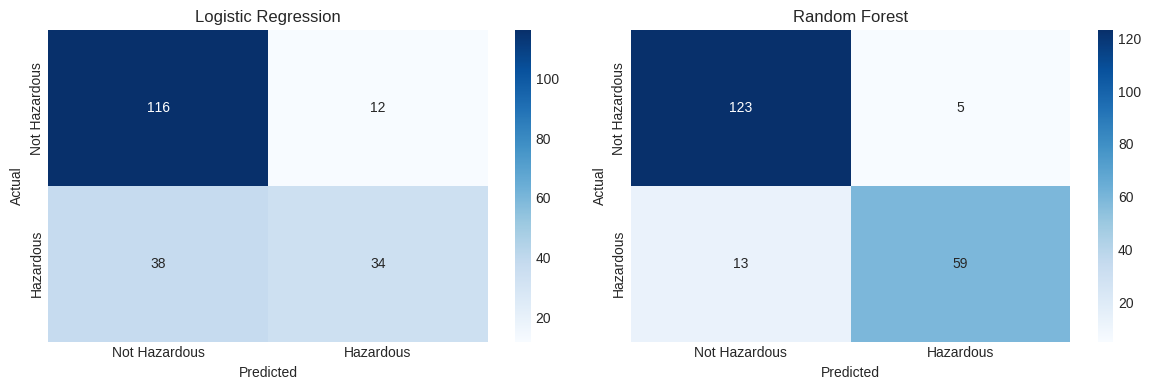

💭 Which model misses fewer actual hazardous asteroids?
   False Negatives (bottom-left) = missed hazardous = DANGEROUS


In [ ]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Hazardous', 'Hazardous'],
                yticklabels=['Not Hazardous', 'Hazardous'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print('Which model misses fewer actual hazardous asteroids?')
print('False Negatives (bottom-left) = missed hazardous = DANGEROUS')

## 8. Feature Importance

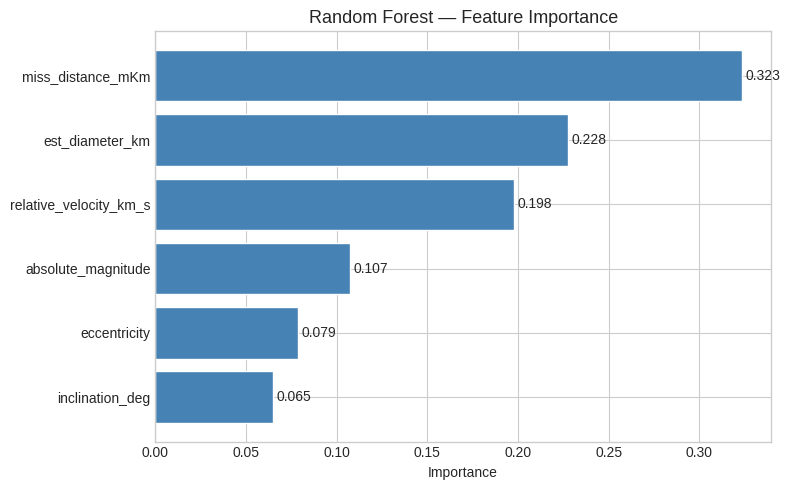

💭 Which features matter most? Does this make physical sense?


In [ ]:
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importance', fontsize=13)
ax.set_xlabel('Importance')

for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Which features matter most? Does this make physical sense?')

## 9. Save Model

In [ ]:
import joblib

joblib.dump(rf, 'asteroid_model.pkl')
joblib.dump(FEATURES, 'asteroid_features.pkl')

print('Model saved: asteroid_model.pkl')
print('Features saved: asteroid_features.pkl')
print()
print('These files will be used in:')
print('  → app.py (Streamlit visualization)')
print('  → Week 2: api.py (FastAPI deployment)')

✅ Model saved: asteroid_model.pkl
✅ Features saved: asteroid_features.pkl

These files will be used in:
  → app.py (Streamlit visualization)
  → Week 2: api.py (FastAPI deployment)


## 10. Misclassification Analysis

Which asteroids are incorrectly predicted by the model? Is there any common pattern among them?

In [ ]:
# Get misclassified samples
misclassified_mask = y_pred_rf != y_test.values
misclassified_df = X_test[misclassified_mask].copy()
misclassified_df['true_label'] = y_test.values[misclassified_mask]
misclassified_df['predicted_label'] = y_pred_rf[misclassified_mask]
misclassified_df['error_type'] = misclassified_df.apply(
    lambda row: 'False Negative (Missed Hazardous)' if row['true_label'] == 1 else 'False Positive (False Alarm)',
    axis=1
)

print(f'Total misclassified: {len(misclassified_df)} out of {len(y_test)} ({len(misclassified_df)/len(y_test)*100:.1f}%)')
print(f'\nError type breakdown:')
print(misclassified_df['error_type'].value_counts())
print(f'\nMisclassified asteroids details:')
misclassified_df

In [ ]:
# Visualize misclassified vs correctly classified distributions
correct_mask = ~misclassified_mask
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    # Correctly classified
    ax.hist(X_test[correct_mask][feat], alpha=0.5, label='Correct', color='steelblue', bins=25)
    # Misclassified
    ax.hist(X_test[misclassified_mask][feat], alpha=0.7, label='Misclassified', color='tomato', bins=25)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions: Correctly Classified vs Misclassified', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Statistical summary of misclassified samples
print('\n📊 Misclassified samples — Statistical Summary:')
print(misclassified_df[FEATURES].describe().round(3))
print('\n📊 All test samples — Statistical Summary:')
print(X_test[FEATURES].describe().round(3))

## 11. Confidence Analysis

Identify the predictions where the model is **most confident** and **most uncertain**.
Analyze how confidence relates to correct vs incorrect predictions.

In [ ]:
# Get prediction probabilities
y_proba_rf = rf.predict_proba(X_test)
confidence = np.max(y_proba_rf, axis=1)  # Max probability = confidence level
hazard_proba = y_proba_rf[:, 1]  # Probability of being hazardous

# Create analysis dataframe
confidence_df = X_test.copy()
confidence_df['true_label'] = y_test.values
confidence_df['predicted_label'] = y_pred_rf
confidence_df['hazard_probability'] = hazard_proba
confidence_df['confidence'] = confidence
confidence_df['correct'] = (y_pred_rf == y_test.values)

# Most confident predictions
print('🟢 TOP 10 MOST CONFIDENT predictions:')
top_confident = confidence_df.nlargest(10, 'confidence')
display(top_confident[['hazard_probability', 'confidence', 'true_label', 'predicted_label', 'correct']])

print('\n🔴 TOP 10 MOST UNCERTAIN predictions:')
top_uncertain = confidence_df.nsmallest(10, 'confidence')
display(top_uncertain[['hazard_probability', 'confidence', 'true_label', 'predicted_label', 'correct']])

In [ ]:
# Confidence distribution: correct vs incorrect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confidence distribution by correctness
ax = axes[0]
ax.hist(confidence_df[confidence_df['correct']]['confidence'], 
        alpha=0.6, label='Correct', color='steelblue', bins=20)
ax.hist(confidence_df[~confidence_df['correct']]['confidence'], 
        alpha=0.6, label='Incorrect', color='tomato', bins=20)
ax.set_xlabel('Confidence')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution: Correct vs Incorrect')
ax.legend()

# Plot 2: Hazard probability distribution by true label
ax = axes[1]
ax.hist(confidence_df[confidence_df['true_label'] == 0]['hazard_probability'], 
        alpha=0.6, label='Not Hazardous', color='steelblue', bins=20)
ax.hist(confidence_df[confidence_df['true_label'] == 1]['hazard_probability'], 
        alpha=0.6, label='Hazardous', color='tomato', bins=20)
ax.set_xlabel('Hazard Probability')
ax.set_ylabel('Count')
ax.set_title('Hazard Probability by True Label')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Default Threshold')
ax.legend()

plt.tight_layout()
plt.show()

# Summary stats
print(f'\n📊 Confidence Statistics:')
print(f'  Correct predictions  — mean confidence: {confidence_df[confidence_df["correct"]]["confidence"].mean():.3f}')
print(f'  Incorrect predictions — mean confidence: {confidence_df[~confidence_df["correct"]]["confidence"].mean():.3f}')
print(f'\n  Model is most uncertain about: {"Hazardous" if confidence_df[confidence_df["true_label"]==1]["confidence"].mean() < confidence_df[confidence_df["true_label"]==0]["confidence"].mean() else "Not Hazardous"} asteroids')
print(f'  Avg confidence for true Hazardous:     {confidence_df[confidence_df["true_label"]==1]["confidence"].mean():.3f}')
print(f'  Avg confidence for true Not Hazardous: {confidence_df[confidence_df["true_label"]==0]["confidence"].mean():.3f}')

## 12. Cost-Sensitive Classification Threshold

Assuming that **missing a hazardous asteroid is 100 times more costly** than a false alarm,
find the optimal classification threshold.

- **False Negative (FN)**: Missing a hazardous asteroid → cost = 100
- **False Positive (FP)**: False alarm → cost = 1

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Calculate costs for different thresholds
thresholds = np.arange(0.01, 1.0, 0.01)
costs = []
recalls = []
precisions = []

FN_COST = 100  # Missing a hazardous asteroid
FP_COST = 1    # False alarm

for threshold in thresholds:
    y_pred_t = (hazard_proba >= threshold).astype(int)
    
    # Count FN and FP
    fn = ((y_test.values == 1) & (y_pred_t == 0)).sum()
    fp = ((y_test.values == 0) & (y_pred_t == 1)).sum()
    tp = ((y_test.values == 1) & (y_pred_t == 1)).sum()
    
    total_cost = fn * FN_COST + fp * FP_COST
    recall = tp / max((tp + fn), 1)
    precision = tp / max((tp + fp), 1)
    
    costs.append(total_cost)
    recalls.append(recall)
    precisions.append(precision)

# Find optimal threshold
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

print(f'🎯 Optimal cost-sensitive threshold: {optimal_threshold:.2f}')
print(f'   Minimum total cost: {optimal_cost:.0f}')
print(f'   Recall at optimal threshold: {recalls[optimal_idx]:.3f}')
print(f'   Precision at optimal threshold: {precisions[optimal_idx]:.3f}')
print(f'\n   Default threshold (0.5):')
default_idx = 49  # threshold = 0.50
print(f'   Cost at 0.5: {costs[default_idx]:.0f}')
print(f'   Recall at 0.5: {recalls[default_idx]:.3f}')
print(f'   Precision at 0.5: {precisions[default_idx]:.3f}')

In [ ]:
# Visualize cost vs threshold
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total cost vs threshold
ax = axes[0]
ax.plot(thresholds, costs, color='tomato', linewidth=2)
ax.axvline(optimal_threshold, color='green', linestyle='--', 
           label=f'Optimal: {optimal_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default: 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('Total Cost')
ax.set_title(f'Cost-Sensitive Analysis\n(FN cost={FN_COST}×, FP cost={FP_COST}×)')
ax.legend()

# Plot 2: Recall vs threshold
ax = axes[1]
ax.plot(thresholds, recalls, color='steelblue', linewidth=2)
ax.axvline(optimal_threshold, color='green', linestyle='--',
           label=f'Optimal: {optimal_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default: 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('Recall')
ax.set_title('Recall vs Threshold')
ax.legend()

# Plot 3: Precision vs Recall
ax = axes[2]
ax.plot(precisions, recalls, color='purple', linewidth=2)
ax.scatter([precisions[optimal_idx]], [recalls[optimal_idx]], 
           color='green', s=100, zorder=5, label=f'Optimal (t={optimal_threshold:.2f})')
ax.scatter([precisions[default_idx]], [recalls[default_idx]], 
           color='gray', s=100, zorder=5, label='Default (t=0.50)')
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Precision-Recall Trade-off')
ax.legend()

plt.tight_layout()
plt.show()

# Show confusion matrix at optimal threshold
y_pred_optimal = (hazard_proba >= optimal_threshold).astype(int)
print(f'\n📊 Confusion Matrix at Optimal Threshold ({optimal_threshold:.2f}):')
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
print(f'   TN={cm_optimal[0,0]}, FP={cm_optimal[0,1]}')
print(f'   FN={cm_optimal[1,0]}, TP={cm_optimal[1,1]}')
print(f'\n{classification_report(y_test, y_pred_optimal, target_names=["Not Hazardous", "Hazardous"])}')

## 13. [Optional] n_estimators Comparison: 50 vs 100 vs 200

How does changing the number of trees affect model performance?

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for n_est in [50, 100, 200]:
    rf_temp = RandomForestClassifier(n_estimators=n_est, random_state=42)
    rf_temp.fit(X_train, y_train)
    y_pred_temp = rf_temp.predict(X_test)
    y_proba_temp = rf_temp.predict_proba(X_test)[:, 1]
    
    results.append({
        'n_estimators': n_est,
        'Accuracy': accuracy_score(y_test, y_pred_temp),
        'Precision': precision_score(y_test, y_pred_temp),
        'Recall': recall_score(y_test, y_pred_temp),
        'F1': f1_score(y_test, y_pred_temp),
        'ROC-AUC': roc_auc_score(y_test, y_proba_temp)
    })

results_df = pd.DataFrame(results).set_index('n_estimators')
print('📊 Model Performance Comparison:')
display(results_df.round(4))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Random Forest Performance: n_estimators Comparison')
ax.set_ylabel('Score')
ax.set_xlabel('n_estimators')
ax.set_ylim(0.8, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. [Optional] New Feature: velocity_diameter_ratio

Add `velocity_diameter_ratio = relative_velocity_km_s / est_diameter_km` and evaluate its impact.

In [ ]:
# Add new feature
df['velocity_diameter_ratio'] = df['relative_velocity_km_s'] / df['est_diameter_km']

FEATURES_NEW = FEATURES + ['velocity_diameter_ratio']

X_new = df[FEATURES_NEW]
y_new = df['is_hazardous']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# Train new model
rf_new = RandomForestClassifier(n_estimators=100, random_state=42)
rf_new.fit(X_train_new, y_train_new)

y_pred_new = rf_new.predict(X_test_new)
y_proba_new = rf_new.predict_proba(X_test_new)[:, 1]

print('📊 Model with new feature (velocity_diameter_ratio):')
print(f'  Accuracy:  {accuracy_score(y_test_new, y_pred_new):.4f}')
print(f'  Precision: {precision_score(y_test_new, y_pred_new):.4f}')
print(f'  Recall:    {recall_score(y_test_new, y_pred_new):.4f}')
print(f'  F1:        {f1_score(y_test_new, y_pred_new):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_test_new, y_proba_new):.4f}')
print(f'\n{classification_report(y_test_new, y_pred_new, target_names=["Not Hazardous", "Hazardous"])}')

# Feature importance comparison
importance_new_df = pd.DataFrame({
    'feature': FEATURES_NEW,
    'importance': rf_new.feature_importances_
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
ax = axes[0]
importance_df.plot.barh(x='feature', y='importance', ax=ax, color='steelblue', legend=False)
ax.set_title('Original Feature Importance')
ax.set_xlabel('Importance')

# New
ax = axes[1]
colors = ['tomato' if f == 'velocity_diameter_ratio' else 'steelblue' for f in importance_new_df['feature']]
ax.barh(importance_new_df['feature'], importance_new_df['importance'], color=colors)
ax.set_title('Feature Importance with velocity_diameter_ratio')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Where does the new feature rank?
rank = importance_new_df.reset_index(drop=True)
rank['rank'] = range(len(rank), 0, -1)
new_feat_rank = rank[rank['feature'] == 'velocity_diameter_ratio']['rank'].values[0]
print(f'\n🏆 velocity_diameter_ratio ranks #{new_feat_rank} out of {len(FEATURES_NEW)} features')
print(f'   Importance score: {rank[rank["feature"] == "velocity_diameter_ratio"]["importance"].values[0]:.4f}')